## Import Libraries and Dataset

In [1]:
#Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math as math

from scipy.stats import randint 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV,StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import brier_score_loss, roc_curve, precision_recall_curve


## Import CSV data 
**Fix Date Format**
mm/dd/yyyy --> yyyy-mm-dd

In [2]:
# Import csv dataset with column description
# Set up to read date fields as dates
date_columns = ['vdate', 'discharged']
los_data = pd.read_csv("LengthOfStay.csv", parse_dates=date_columns)

# Check contents of dataset
print(los_data.head())

   eid      vdate rcount gender  dialysisrenalendstage  asthma  irondef  \
0    1 2012-08-29      0      F                      0       0        0   
1    2 2012-05-26     5+      F                      0       0        0   
2    3 2012-09-22      1      F                      0       0        0   
3    4 2012-08-09      0      F                      0       0        0   
4    5 2012-12-20      0      F                      0       0        0   

   pneum  substancedependence  psychologicaldisordermajor  ...     glucose  \
0      0                    0                           0  ...  192.476918   
1      0                    0                           0  ...   94.078507   
2      0                    0                           0  ...  130.530524   
3      0                    0                           0  ...  163.377028   
4      1                    0                           1  ...   94.886654   

   bloodureanitro  creatinine        bmi  pulse  respiration  \
0            12.

## Categorical 
- End Stage Renal Failure (Receiving Dialysis)- dialysisrenalendstage
- Asthma - asthma
- Iron Deficiency - irondef
- Pneumonia - pneum
- Substance Use Disorder - substancedependence
- Major Psychological Disorder - psychologicaldisordermajor
- Depression - depress
- Other Psychological Disorder - psychother
- Fibrosis - fibrosisandother
- Malnutrition - malnutrition
- Blood disorder - hemo
- Readmission count (from the last 180 days) - rcount

## Continuous 
- Hematocrit (g/dL) - hematocrit
- Neutrophil Presence (cells/μL) - neutrophils
- Sodium Levels (mmol\L) - sodium
- Blood Glucose Levels (mg/dL) - glucose
- Blood Urea Nitrogen Levels (mg/dL) - bloodureanitro
- Creatinine Levels (mg/dL) - creatinine
- BMI (kg/m²) - bmi
- Pulse (beats/min)- pulse
- Respiration Rate (breaths/min) - respiration

## Create Target Variable:
extended_los (LOS >= 7)

In [3]:
# Transform lengthofstay to binary field
# Create a Boolean field name longlengthstay
# If lengthofstay Less that 7 days set longlengthofstay to 0 if >= 7 days set longlengthofstay to 1

los_data['extended_los'] = los_data['lengthofstay'] >= 7

## Check for Missing (NA) values

In [4]:
# Check for NA values
missing_counts = los_data.isnull().sum()

var_with_NA = missing_counts[missing_counts > 0]

#report 
if var_with_NA.empty:
    print("No missing values.")
    missing = False
else:
    print("Variables containing missing values are:")
    print(var_with_NA)
    print("Apply one of the methods below to fill missing values.")
    missing = True

No missing values.


## Drop unesscary columns


In [5]:
# Drop unneeded columns
column_to_drop = ['gender', 'lengthofstay', 'eid', 'vdate', 'discharged', 'secondarydiagnosisnonicd9']
los_data_cleaned = los_data.drop(column_to_drop, axis=1)

## Correct rcount
Current values 0, 1, 2, 3, 4, 5+
5+ comes in as a string and needs to be adjusted to an int. Will use 5 for now.

In [7]:
# Fix the rcount field
# Replace '5+' with '5'
los_data_cleaned['rcount'] = los_data_cleaned['rcount'].astype(str) 
los_data_cleaned['rcount'] = los_data_cleaned['rcount'].str.replace('5+', '5', regex=False)

## Spilt into Training and Test data

In [8]:
# Spilt into feature and target variables
X = los_data_cleaned.drop(columns=['extended_los'])
y = los_data_cleaned['extended_los'].astype(int)
print(X)
print(y)

# SPLIT DATA INTO TRAINING AND VALIDATION SET
trainX, testX, trainY, testY = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

      rcount  dialysisrenalendstage  asthma  irondef  pneum  \
0          0                      0       0        0      0   
1          5                      0       0        0      0   
2          1                      0       0        0      0   
3          0                      0       0        0      0   
4          0                      0       0        0      1   
...      ...                    ...     ...      ...    ...   
99995      3                      0       0        0      0   
99996      0                      0       0        0      0   
99997      1                      0       0        1      0   
99998      0                      0       0        0      0   
99999      0                      0       0        0      0   

       substancedependence  psychologicaldisordermajor  depress  psychother  \
0                        0                           0        0           0   
1                        0                           0        0           0   
2     

## Descriptive Statistics of Training and Test Cohort
Comorbidities,
Facilities,
Count of Readmissions, and
Clinical Measures Table

In [12]:
binary_vars = [
    'asthma','dialysisrenalendstage','irondef','pneum',
    'substancedependence','psychologicaldisordermajor','depress',
    'psychother','fibrosisandother','malnutrition','hemo'
]
def make_descriptive_table(df, categorical=None, continuous=None, binary=None):
    if categorical is None:
        categorical = df.select_dtypes(include=['object', 'category']).columns.tolist()
    if continuous is None:
        continuous = [c for c in df.select_dtypes(include=[np.number]).columns if c not in (binary or [])]
    if binary is None:
        binary = []
    rows = []

    # Continuous variables
    for col in continuous:
        series = df[col].dropna()
        row = {
            "Variable": col,
            "Type": "Continuous",
            "N": series.shape[0],
            "Mean (SD)": f"{series.mean():.2f} ({series.std():.2f})",
            "Median [IQR]": f"{series.median():.2f} [{series.quantile(0.25):.2f}-{series.quantile(0.75):.2f}]",
            "Missing": df[col].isna().sum()
        }
        rows.append(row)

    # Binary variables 
    for col in binary:
        counts = df[col].value_counts(dropna=False).sort_index()
        for level, count in counts.items():
            row = {
                "Variable": col,
                "Type": "Binary",
                "Level": level,
                "N": count,
                "Percent": f"{100*count/len(df):.1f}%",
                "Missing": df[col].isna().sum()
            }
            rows.append(row)

    # Categorical variables 
    for col in categorical:
        counts = df[col].value_counts(dropna=False)
        for level, count in counts.items():
            row = {
                "Variable": col,
                "Type": "Categorical",
                "Level": level,
                "N": count,
                "Percent": f"{100*count/len(df):.1f}%",
                "Missing": df[col].isna().sum()
            }
            rows.append(row)

    return pd.DataFrame(rows)

train_table = make_descriptive_table(trainX, binary=binary_vars)
test_table = make_descriptive_table(testX, binary=binary_vars)

# Add dataset label
train_table["Dataset"] = "Train"
test_table["Dataset"] = "Test"

# Combine
table1 = pd.concat([train_table, test_table], ignore_index=True)

table1 = table1[["Dataset","Variable","Type","Level","N","Percent","Mean (SD)","Median [IQR]","Missing"]]

# Preview
table1


,Dataset,Variable,Type,Level,N,Percent,Mean (SD),Median [IQR],Missing
0,Train,hematocrit,Continuous,NaN,80000,NaN,11.97 (2.03),11.90 [10.90-12.90],0
1,Train,neutrophils,Continuous,NaN,80000,NaN,10.18 (5.34),9.40 [7.70-11.50],0
2,Train,sodium,Continuous,NaN,80000,NaN,137.89 (3.00),137.89 [135.88-139.91],0
3,Train,glucose,Continuous,NaN,80000,NaN,141.91 (29.95),142.04 [121.60-162.08],0
4,Train,bloodureanitro,Continuous,NaN,80000,NaN,14.11 (13.15),12.00 [11.00-14.00],0
...,...,...,...,...,...,...,...,...,...
79,Test,facid,Categorical,E,6159,30.8%,NaN,NaN,0
80,Test,facid,Categorical,B,6010,30.1%,NaN,NaN,0
81,Test,facid,Categorical,A,5988,29.9%,NaN,NaN,0
82,Test,facid,Categorical,C,977,4.9%,NaN,NaN,0


## Exploratory Data Analysis

*** Distribution of variables ***

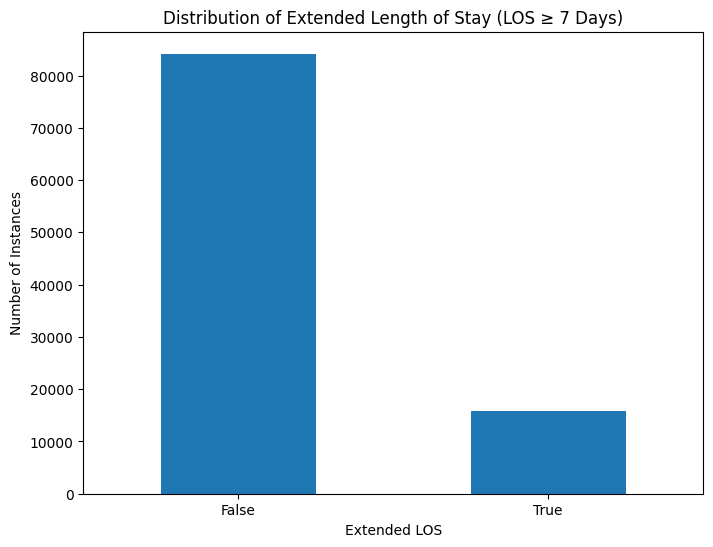

In [9]:
# Extended LOS 
class_counts = los_data_cleaned['extended_los'].value_counts()

plt.figure(figsize=(8, 6))
class_counts.plot(kind='bar')
plt.title('Distribution of Extended Length of Stay (LOS ≥ 7 Days)')
plt.xlabel('Extended LOS')
plt.ylabel('Number of Instances')
plt.xticks(rotation=0) # Keeps x-axis labels horizontal
plt.show()

****There is imbalanced data of extended LOS.****

We will need to handle imbalanced data by choosing class_weight = 'balanced'

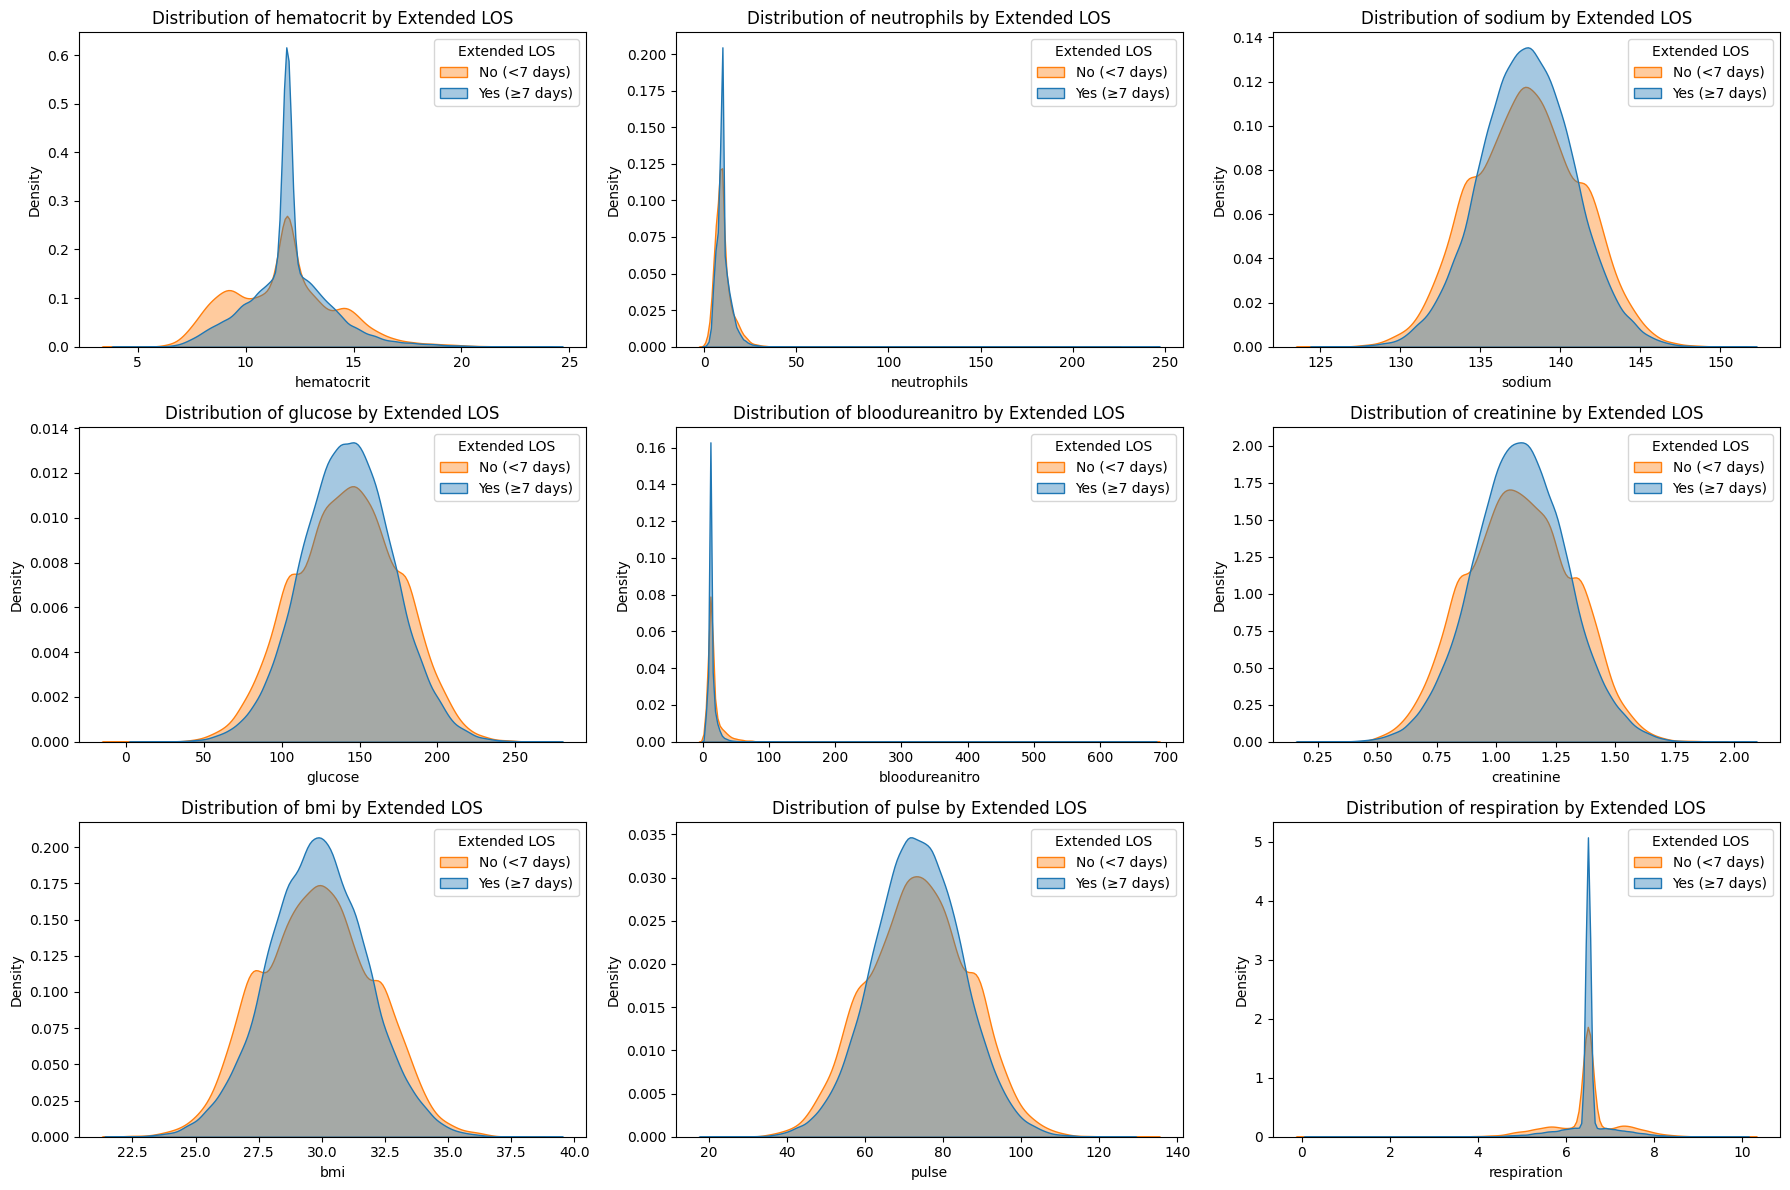

In [13]:
# Select continuous variables (numeric only, excluding the outcome column)
continuous_vars = ['hematocrit', 'neutrophils', 'sodium', 'glucose', 
                   'bloodureanitro', 'creatinine', 'bmi', 'pulse', 'respiration']
n_features = len(continuous_vars)

n_cols = 3
n_rows = math.ceil(n_features / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*6, n_rows*4))
axes = axes.flatten()  

for i, col in enumerate(continuous_vars):
    sns.kdeplot(
        data=los_data_cleaned, 
        x=col, 
        hue="extended_los", 
        common_norm=False, 
        fill=True, 
        alpha=0.4, 
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {col} by Extended LOS")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")
    axes[i].legend(title="Extended LOS", labels=["No (<7 days)", "Yes (≥7 days)"])

# Remove unused axes 
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

****Normal Distribution based on the plots: sodium, glucose, creatinine, BMI, pulse****
- Will need to z-score standadization

****Skewed/Non-nomral distribution: hematocrit, neutrophils, bloodreanitro, respiration****
- Will need to do logarithmic transformation before standardizing 

## Feature Grouping and Transformers
- Impute by (continuous) median or (categorical) most frequent if there are any missing values. (just in case)
- Continuous (labs, vitals) : log (if skewed) and standardize
- Categories (rcount) : one-hot encode
- Nominal categories (facid) : one-hot encode

In [11]:
# Treat Rcount and Facid as category
for df in [trainX, testX]:
    df["rcount"] = df["rcount"].astype("category")
    df["facid"]  = df["facid"].astype("category")

In [12]:
# Define your groups
log_vars     = ['hematocrit', 'neutrophils', 'bloodureanitro']
other_vars   = ['sodium', 'glucose', 'creatinine', 'bmi', 'pulse', 'respiration']
binary_vars  = [
    'asthma','dialysisrenalendstage','irondef','pneum',
    'substancedependence','psychologicaldisordermajor','depress',
    'psychother','fibrosisandother','malnutrition','hemo']
cat_vars = ['rcount', 'facid']

# Transformers for each group
log_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p, validate=False)),  
    ("scaler", StandardScaler())
])

other_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

binary_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
    # no scaler, no encoder → keep as 0/1
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("log_num", log_transformer, log_vars),
        ("num", other_numeric_transformer, other_vars),
        ("bin", binary_transformer, binary_vars),
        ("cat", categorical_transformer, cat_vars),
    ],
    remainder="drop"
)


## Model Pipeline
Create model pipeline from preprocessing 
- Logistic Regression 
- Random Forest

In [19]:
logreg_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", LogisticRegression(
        class_weight="balanced",
        solver="liblinear",     
        max_iter=5000,
        random_state=42
    ))
])

rf_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(
        class_weight="balanced",
        n_estimators=500,
        n_jobs=-1,
        random_state=42
    ))
])

## Hyperparameter Tuning & Model Selection
- GridSearchCV (LR)
- Randomized Search (RF) due to too many variables 
- Cross-validation and metrics (ROC_AUC and PR_AUC)

In [14]:
# Define Cross-Validation strategy and metrics
# Stratified CV (keeps class ratios balanced across folds)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc":  "average_precision"
}

****LR****

In [20]:
# Logistic Regression hyperparameter distributions 
log_params = {
    "clf__penalty": ["l1", "l2"],
    "clf__C": [0.01, 0.1, 1, 10, 100]
}

log_cv = GridSearchCV(
    estimator=logreg_pipe,
    param_grid=log_params,
    cv=cv,
    scoring=scoring,     
    refit="pr_auc",      # PR-AUC (good for imbalance)
    n_jobs=-1,
    verbose=1,
    error_score="raise",
    return_train_score=True
)

log_cv.fit(trainX, trainY)

best_idx = log_cv.best_index_

print("Best params:", log_cv.best_params_)
print("Mean PR-AUC (CV, best):",  log_cv.cv_results_["mean_test_pr_auc"][best_idx])
print("Mean ROC-AUC (CV, same):", log_cv.cv_results_["mean_test_roc_auc"][best_idx])

# Best fitted pipeline/model
best_lr = log_cv.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'clf__C': 0.1, 'clf__penalty': 'l1'}
Mean PR-AUC (CV, best): 0.8557127463708426
Mean ROC-AUC (CV, same): 0.9523712871356913


****RF****

In [18]:
# Random Forest hyperparameter distributions 
rf_param_dist = {
    "clf__n_estimators": randint(100, 201),      
    "clf__max_depth": [None, 10, 20, 30],
    "clf__min_samples_split": randint(2, 11),    
    "clf__min_samples_leaf": randint(1, 5),      
    "clf__max_features": ["sqrt", "log2"],
}

rf_cv = RandomizedSearchCV(
    estimator=rf_pipe,                 
    param_distributions=rf_param_dist,
    n_iter=30,
    cv=cv,
    scoring=scoring,                 
    refit="pr_auc",                        
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True
)

# Fit search
rf_cv.fit(trainX, trainY)

print("Best Params:", rf_cv.best_params_)
print("Best PR AUC (CV):", rf_cv.best_score_)
print("Best ROC AUC for that model:",
      rf_cv.cv_results_[f'mean_test_roc_auc'][rf_cv.best_index_])


# Best fitted pipeline/model
best_rf = rf_cv.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Params: {'clf__max_depth': None, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 9, 'clf__n_estimators': 187}
Best PR AUC (CV): 0.9430892700650165
Best ROC AUC for that model: 0.9865641503635011


## Results of LR and RF CV 

In [21]:
# Logistic Regression CV results
log_results = pd.DataFrame(log_cv.cv_results_)
log_results = log_results[[
    "params", 
    "mean_test_roc_auc", "rank_test_roc_auc",
    "mean_test_pr_auc",  "rank_test_pr_auc"
]].sort_values("rank_test_pr_auc")

# Random Forest CV results
rf_results = pd.DataFrame(rf_cv.cv_results_)

# include both ROC-AUC and PR-AUC
rf_results = rf_results[[
    "params", 
    "mean_test_roc_auc", "rank_test_roc_auc",
    "mean_test_pr_auc",  "rank_test_pr_auc"
]].sort_values("rank_test_pr_auc")   # sort by PR AUC rank

# Display top 10 parameter combinations for each model
display(log_results.head(10))
display(rf_results.head(10))


,params,mean_test_roc_auc,rank_test_roc_auc,mean_test_pr_auc,rank_test_pr_auc
2,"{'clf__C': 0.1, 'clf__penalty': 'l1'}",0.952371,7,0.855713,1
3,"{'clf__C': 0.1, 'clf__penalty': 'l2'}",0.952357,8,0.855712,2
5,"{'clf__C': 1, 'clf__penalty': 'l2'}",0.952404,6,0.855685,3
4,"{'clf__C': 1, 'clf__penalty': 'l1'}",0.952406,5,0.855681,4
6,"{'clf__C': 10, 'clf__penalty': 'l1'}",0.952407,3,0.855669,5
8,"{'clf__C': 100, 'clf__penalty': 'l1'}",0.952407,1,0.855669,6
7,"{'clf__C': 10, 'clf__penalty': 'l2'}",0.952406,4,0.855669,7
9,"{'clf__C': 100, 'clf__penalty': 'l2'}",0.952407,2,0.855668,8
0,"{'clf__C': 0.01, 'clf__penalty': 'l1'}",0.951409,10,0.854346,9
1,"{'clf__C': 0.01, 'clf__penalty': 'l2'}",0.951825,9,0.853709,10


,params,mean_test_roc_auc,rank_test_roc_auc,mean_test_pr_auc,rank_test_pr_auc
22,"{'clf__max_depth': None, 'clf__max_features': ...",0.986564,1,0.943089,1
25,"{'clf__max_depth': 30, 'clf__max_features': 's...",0.986478,2,0.942620,2
8,"{'clf__max_depth': 30, 'clf__max_features': 'l...",0.986376,3,0.942491,3
1,"{'clf__max_depth': None, 'clf__max_features': ...",0.985901,5,0.941145,4
5,"{'clf__max_depth': 30, 'clf__max_features': 'l...",0.986100,4,0.941133,5
19,"{'clf__max_depth': 30, 'clf__max_features': 's...",0.985775,6,0.940829,6
14,"{'clf__max_depth': 30, 'clf__max_features': 'l...",0.985543,7,0.940292,7
16,"{'clf__max_depth': 30, 'clf__max_features': 'l...",0.984957,8,0.938280,8
28,"{'clf__max_depth': 30, 'clf__max_features': 'l...",0.984746,9,0.937722,9
3,"{'clf__max_depth': 30, 'clf__max_features': 'l...",0.984715,10,0.937707,10


## Evaluate on Training Data

* Use threshold of 0.05

In [22]:
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, classification_report

# Logistic Regression
y_proba_log_train = best_lr.predict_proba(trainX)[:, 1]
y_pred_log_train = (y_proba_log_train >= 0.05).astype(int)  
print("ROC-AUC:", roc_auc_score(trainY, y_proba_log_train))
print("PR-AUC:", average_precision_score(trainY, y_proba_log_train))
print(classification_report(trainY, y_pred_log_train))


# Random Forest
y_proba_rf_train = best_rf.predict_proba(trainX)[:, 1]
y_pred_rf_train = (y_proba_rf_train >= 0.05).astype(int)
print("ROC-AUC:", roc_auc_score(trainY, y_proba_rf_train))
print("PR-AUC:", average_precision_score(trainY, y_proba_rf_train))
print(classification_report(trainY, y_pred_rf_train))

ROC-AUC: 0.9527822611799105
PR-AUC: 0.8564131395131689
              precision    recall  f1-score   support

           0       1.00      0.40      0.57     67338
           1       0.24      0.99      0.38     12662

    accuracy                           0.50     80000
   macro avg       0.62      0.70      0.48     80000
weighted avg       0.88      0.50      0.54     80000

ROC-AUC: 0.9999137331832308
PR-AUC: 0.9995356935272903
              precision    recall  f1-score   support

           0       1.00      0.74      0.85     67338
           1       0.42      1.00      0.59     12662

    accuracy                           0.78     80000
   macro avg       0.71      0.87      0.72     80000
weighted avg       0.91      0.78      0.81     80000



## Evaluate on Test Data

In [ ]:
# Logistic Regression
y_proba_log = best_lr.predict_proba(testX)[:, 1]
y_pred_log = (y_proba_log >= 0.05).astype(int) 
print("ROC-AUC:", roc_auc_score(testY, y_proba_log))
print("PR-AUC:", average_precision_score(testY, y_proba_log))
print(classification_report(testY, y_pred_log))


# Random Forest
y_proba_rf = best_rf.predict_proba(testX)[:, 1]
y_pred_rf = (y_proba_rf >= 0.05).astype(int)
print("ROC-AUC:", roc_auc_score(testY, y_proba_rf))
print("PR-AUC:", average_precision_score(testY, y_proba_rf))
print(classification_report(testY, y_pred_rf))

ROC-AUC: 0.9514303618455294
PR-AUC: 0.8550658039731411
              precision    recall  f1-score   support

           0       1.00      0.41      0.58     16834
           1       0.24      0.99      0.39      3166

    accuracy                           0.50     20000
   macro avg       0.62      0.70      0.48     20000
weighted avg       0.88      0.50      0.55     20000

ROC-AUC: 0.986312820420064
PR-AUC: 0.9432804326070019
              precision    recall  f1-score   support

           0       1.00      0.70      0.82     16834
           1       0.39      1.00      0.56      3166

    accuracy                           0.75     20000
   macro avg       0.69      0.85      0.69     20000
weighted avg       0.90      0.75      0.78     20000



## Plot Metrics Results

- Training 

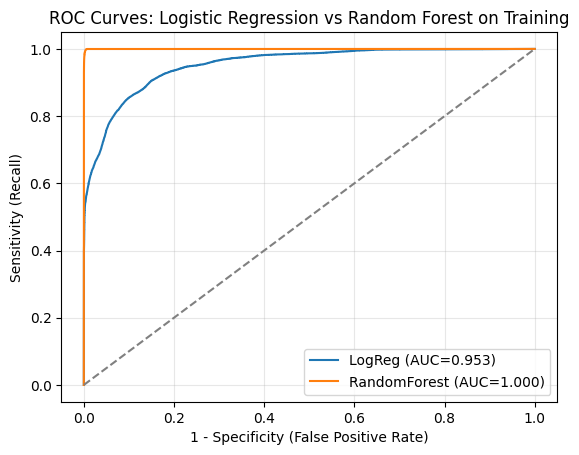

                 Model    AUC  Sensitivity  Specificity  Brier score
0  Logistic Regression  0.953        0.994        0.402        0.084
1        Random Forest  1.000        1.000        0.742        0.014


In [24]:
fpr_log, tpr_log, _ = roc_curve(trainY, y_proba_log_train)
fpr_rf,  tpr_rf,  _ = roc_curve(trainY, y_proba_rf_train)

plt.figure()
plt.plot(fpr_log, tpr_log, label=f"LogReg (AUC={roc_auc_score(trainY, y_proba_log_train):.3f})")
plt.plot(fpr_rf,  tpr_rf,  label=f"RandomForest (AUC={roc_auc_score(trainY, y_proba_rf_train):.3f})")
plt.plot([0,1], [0,1], linestyle="dashed", color="gray")

plt.xlabel("1 - Specificity (False Positive Rate)")
plt.ylabel("Sensitivity (Recall)")
plt.title("ROC Curves: Logistic Regression vs Random Forest on Training")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Summary Table
def metrics_summary(name, y_true, y_proba, threshold=0.05):
    # threshold predictions
    y_pred = (y_proba >= threshold).astype(int)
    
    # confusion matrix parts
    tp = np.sum((y_true==1) & (y_pred==1))
    tn = np.sum((y_true==0) & (y_pred==0))
    fp = np.sum((y_true==0) & (y_pred==1))
    fn = np.sum((y_true==1) & (y_pred==0))
    
    sensitivity = tp / (tp+fn+1e-12)
    specificity = tn / (tn+fp+1e-12)
    
    auc = roc_auc_score(y_true, y_proba)
    brier = brier_score_loss(y_true, y_proba)
    
    return {
        "Model": name,
        "AUC": auc,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Brier score": brier
    }

results = []
results.append(metrics_summary("Logistic Regression", trainY, y_proba_log_train, threshold=0.05))
results.append(metrics_summary("Random Forest", trainY, y_proba_rf_train, threshold=0.05))

import pandas as pd
df_results = pd.DataFrame(results)
print(df_results.round(3))


- Testing

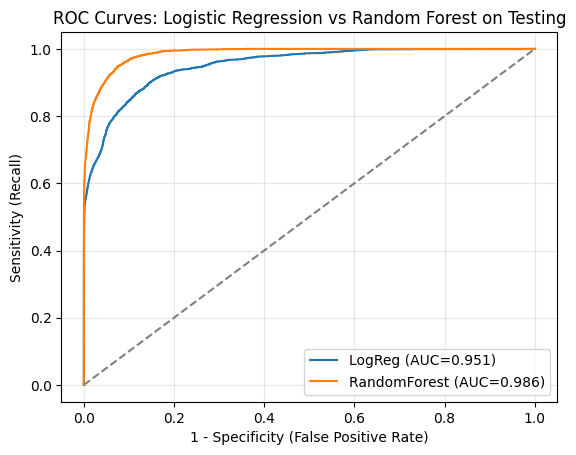

                 Model    AUC  Sensitivity  Specificity  Brier score
0  Logistic Regression  0.951        0.994        0.407        0.084
1        Random Forest  0.986        0.999        0.701        0.036


In [ ]:
# Compute ROC curves
fpr_log, tpr_log, _ = roc_curve(testY, y_proba_log)
fpr_rf,  tpr_rf,  _ = roc_curve(testY, y_proba_rf)

plt.figure()
plt.plot(fpr_log, tpr_log, label=f"LogReg (AUC={roc_auc_score(testY, y_proba_log):.3f})")
plt.plot(fpr_rf,  tpr_rf,  label=f"RandomForest (AUC={roc_auc_score(testY, y_proba_rf):.3f})")
plt.plot([0,1], [0,1], linestyle="dashed", color="gray")

plt.xlabel("1 - Specificity (False Positive Rate)")
plt.ylabel("Sensitivity (Recall)")
plt.title("ROC Curves: Logistic Regression vs Random Forest on Testing")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Summary Table
def metrics_summary(name, y_true, y_proba, threshold=0.05):
    # threshold predictions
    y_pred = (y_proba >= threshold).astype(int)
    
    # confusion matrix parts
    tp = np.sum((y_true==1) & (y_pred==1))
    tn = np.sum((y_true==0) & (y_pred==0))
    fp = np.sum((y_true==0) & (y_pred==1))
    fn = np.sum((y_true==1) & (y_pred==0))
    
    sensitivity = tp / (tp+fn+1e-12)
    specificity = tn / (tn+fp+1e-12)
    
    auc = roc_auc_score(y_true, y_proba)
    brier = brier_score_loss(y_true, y_proba)
    
    return {
        "Model": name,
        "AUC": auc,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Brier score": brier
    }

results = []
results.append(metrics_summary("Logistic Regression", testY, y_proba_log, threshold=0.05))
results.append(metrics_summary("Random Forest", testY, y_proba_rf, threshold=0.05))

df_results = pd.DataFrame(results)
print(df_results.round(3))



# Precision-Recall Curves on Training and Testing

- Training

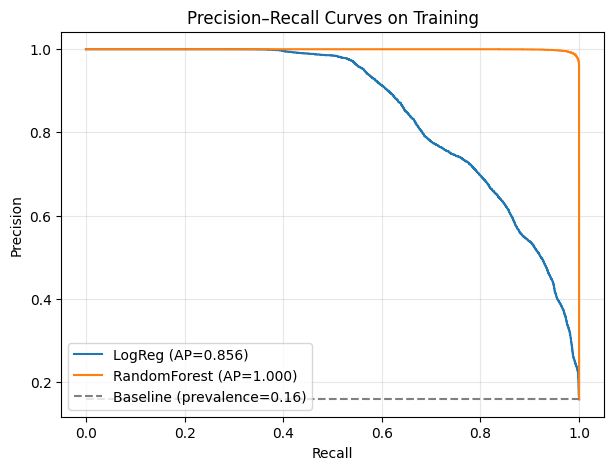

In [26]:
# Curves
prec_log, rec_log, _ = precision_recall_curve(trainY, y_proba_log_train)
prec_rf,  rec_rf,  _ = precision_recall_curve(trainY, y_proba_rf_train)

# Baseline 
baseline = np.mean(trainY)

# Plot PR curves
plt.figure(figsize=(7,5))
plt.plot(rec_log, prec_log, label=f"LogReg (AP={average_precision_score(trainY, y_proba_log_train):.3f})")
plt.plot(rec_rf,  prec_rf,  label=f"RandomForest (AP={average_precision_score(trainY, y_proba_rf_train):.3f})")
plt.hlines(baseline, 0, 1, linestyles="dashed", colors="gray",
           label=f"Baseline (prevalence={baseline:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves on Training")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()


- Testing 

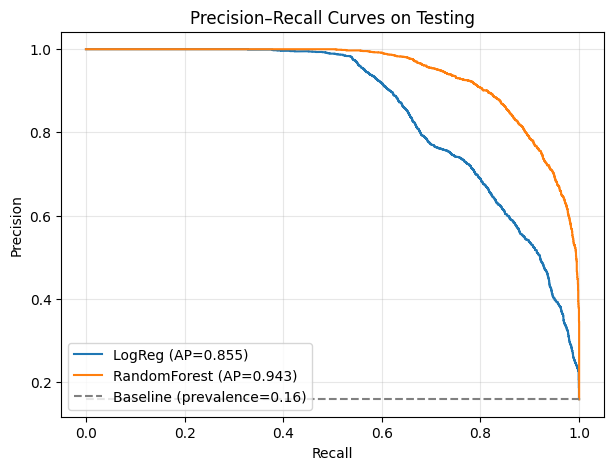

In [27]:
# Curves
prec_log, rec_log, _ = precision_recall_curve(testY, y_proba_log)
prec_rf,  rec_rf,  _ = precision_recall_curve(testY, y_proba_rf)

# Baseline 
baseline = np.mean(testY)

# Plot 
plt.figure(figsize=(7,5))
plt.plot(rec_log, prec_log, label=f"LogReg (AP={average_precision_score(testY, y_proba_log):.3f})")
plt.plot(rec_rf,  prec_rf,  label=f"RandomForest (AP={average_precision_score(testY, y_proba_rf):.3f})")
plt.hlines(baseline, 0, 1, linestyles="dashed", colors="gray",
           label=f"Baseline (prevalence={baseline:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves on Testing")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

## Random Forest Feature Importance

In [ ]:
# Fit the pipeline
rf_pipe.fit(trainX, trainY)

# Extract feature importances from the trained RandomForest
importances = rf_pipe.named_steps["clf"].feature_importances_

# Get transformed feature names from the preprocessor
def get_feature_names(preprocessor, input_features):
    feature_names = []

    for name, transformer, cols in preprocessor.transformers_:
        if transformer == 'drop':
            continue
        elif transformer == 'passthrough':
            # Add original names
            if isinstance(cols, slice):
                cols = input_features[cols]
            feature_names.extend(cols)
        else:
            if hasattr(transformer, 'get_feature_names_out'):
                try:
                    names = transformer.get_feature_names_out(cols)
                except:
                    names = cols  # fallback
            elif hasattr(transformer, 'named_steps'):
                # Try to get from nested pipeline
                last_step = list(transformer.named_steps.values())[-1]
                if hasattr(last_step, 'get_feature_names_out'):
                    names = last_step.get_feature_names_out(cols)
                else:
                    names = cols
            else:
                names = cols
            feature_names.extend(names)

    return feature_names

# Get final feature names
input_features = trainX.columns
feature_names = get_feature_names(rf_pipe.named_steps["pre"], input_features)

# Combine importances with feature names 
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print("Top 15 Feature Importances:")
print(feat_imp.head(15))


plt.figure(figsize=(10, 6))
feat_imp.head(20).plot(kind='barh')
plt.gca().invert_yaxis()  # Highest importance on top
plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


NameError: name 'rf_pipe' is not defined